# Zadanie 1. Warsztat

W warsztacie samochodowym pracuje dwóch mechaników zajmujących się wymianą
filtrów oleju. Obsługa każdego klienta składa się z trzech kolejnych etapów:
diagnozy, wymiany filtra oraz kontroli końcowej. Czas trwania każdego etapu ma
rozkład wykładniczy: dla pierwszego mechanika z parametrem $λ_1 = 5 h^{−1}$,
natomiast dla drugiego z parametrem $λ_2 = 20 h^{−1}$. Prawdopodobieństwo, że
klient trafi do pierwszego mechanika, wynosi 0,2, a do drugiego 0,8. Niech $X$
oznacza całkowity czas obsługi jednego klienta.

1. Oblicz prawdopodobieństwo $P(X > 35min)$. Zwróć uwagę na dobór właściwego
   rozkładu.

2. Oszacuj to prawdopodobieństwo metodą Monte Carlo w taki sposób, aby błąd
   oszacowania nie przekraczał 0,01 z prawdopodobieństwem co najmniej 0,9.

3. Zbadaj wpływ liczby przeprowadzonych symulacji na dokładność otrzymanej
   estymacji.

Dwóch mechaników, wymienia olej.

Składa się to z trzech etapów:
1. diagnozy
2. wymiany filtra
3. QA

Czas każdego etapu ma rozkład wykładniczy:
- pierwszy mechanik ($M_{1}$) - $\lambda_{1} = 5h^{-1}$
- drugi mechanik ($M_{2}$) - $\lambda_{2} = 20h^{-1}$

Prawdopodobieństwo trafienia na mechanika:
- $P(M_{1}) = 0,2$
- $P(M_{2}) = 0,8$

$X_{1}$ - czas wykonania diagnozy, $X_{2}$ - czas wymiany filtra, $X_{3}$ - czas QA

$X = X_{1} + X_{2} + X_{3}$ - całkowity czas obsługi

1. Oblicz prawdopodobieństwo $P(X > 35 minut)$. 
2. Oszacuj to prawdopodobieństwo metodą Monte Carlo w taki sposób, aby błąd oszacowania nie przekraczał $0,01$ z prawdopodobieństwem $P > 0,9$
3. Zbadaj wpływ liczby przeprowadzonych symulacji na dokładność estymacji

## Uzasadnienie rozkładu (punkt 1)
- Dla ustalonego mechanika suma 3 niezależnych czasów wykładniczych o tym samym parametrze $\lambda_k$ ma rozkład Erlanga: $S_k \sim \text{Gamma}(\text{shape}=3, \text{rate}=\lambda_k)$.
- Całkowity czas $X$ jest mieszanką po mechanikach: $P(X>t)=p_1 P(S_1>t)+p_2 P(S_2>t)$.
- W obliczeniach przyjmujemy $t=35/60$ h.

In [1]:
p1 <- 0.2
p2 <- 0.8

lambda1 <- 5
lambda2 <- 20

t_hours <- 35 / 60
p_tail <- p1 * (1 - pgamma(t_hours, shape = 3, rate = lambda1)) + p2 * (1 - pgamma(t_hours, shape = 3, rate = lambda2))

p_tail

[1] 0.08897715

## Punkt 2: estymacja Monte Carlo
- Estymator: $\hat p = \frac{1}{n}\sum_{i=1}^n I_i$, gdzie $I_i = \mathbf{1}\{X_i > t\}$.
- Dobieramy $n$ z przybliżenia CLT: $P(|\hat p - p| \le \varepsilon) \approx 1-\alpha$ oraz $n \approx z_{1-\alpha/2}^2\,p(1-p)/\varepsilon^2$.
- Ponieważ $p$ nie jest znane, stosujemy konserwatywnie $p(1-p) \le 1/4$, więc $n \approx z_{1-\alpha/2}^2/(4\varepsilon^2)$ dla $\alpha=0{,}1$ i $\varepsilon=0{,}01$.


### Uzasadnienie doboru $n$ (CLT) i procedura
- W praktyce korzystamy z wersji konserwatywnej $p(1-p) \le 1/4$, dzięki czemu $n$ nie zależy od nieznanego $p$.
- Po wyznaczeniu $n$ wykonujemy $n$ niezależnych symulacji: losujemy mechanika, generujemy 3 czasy wykładnicze, sumujemy i sprawdzamy $X>t$.
- Estymacja $\hat p$ to średnia z uzyskanych wskaźników $I(X>t)$.

In [3]:
eps <- 0.01
alpha <- 0.1
z <- qnorm(1 - alpha / 2)

n_min <- ceiling((z^2 * 0.25) / (eps^2))

mc_est <- mean(replicate(n_min, {
  lambda <- ifelse(runif(1) < p1, lambda1, lambda2)
  sum(rexp(3, rate = lambda)) > t_hours
}))
mc_est

[1] 0.08382614

**Punkt 3: wpływ liczby symulacji**
- Porównujemy estymacje $\hat p$ dla kilku wartosci $n$ i obserwujemy stabilizacje wyniku wraz ze wzrostem $n$.
- Dla czytelności warto pokazac tabelke $n$ vs $\hat p$ (lub wykres).

In [4]:
n_values <- c(100, 500, 1000, 5000, 10000)
est <- sapply(n_values, function(n) mean(replicate(n, {
  lambda <- ifelse(runif(1) < p1, lambda1, lambda2)
  sum(rexp(3, rate = lambda)) > t_hours
})))
data.frame(n = n_values, p_hat = est)

n,p_hat
<dbl>,<dbl>
100,0.1200
500,0.0780
1000,0.0700
5000,0.0834
10000,0.0880


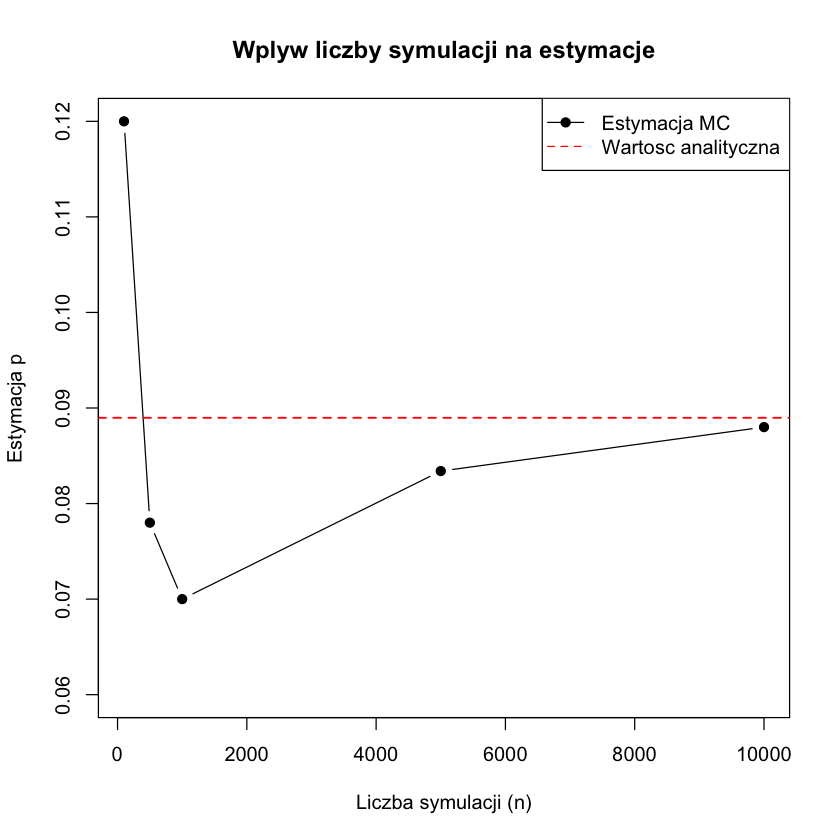

In [7]:
op <- par(bg = "white")
plot(n_values, est, type = "b", pch = 19,
  xlab = "Liczba symulacji (n)", ylab = "Estymacja p",
  main = "Wplyw liczby symulacji na estymacje",
  ylim = c(0.06, 0.12))
abline(h = p_tail, col = "red", lty = 2, lwd = 1.5)
legend("topright", legend = c("Estymacja MC", "Wartosc analityczna"), 
       col = c("black", "red"), lty = c(1, 2), pch = c(19, NA))
par(op)

**Komentarz do wykresu**
- Im wieksza liczba symulacji, tym mniejsza zmienność estymatora $\hat p$ i bardziej stabilny wynik.
- Dla małych $n$ wahania sa wyrazne, a przy duzych $n$ estymacja zbiega do wartosci prawdziwej (prawo wielkich liczb).

## Wyniki i wnioski
- Punkt 1 (analitycznie): $P(X>35\,\text{min}) \approx 0.08898$ (ok. 8.90%).
- Punkt 2 (MC, CLT): minimalna liczba symulacji $n_{\min}=6764$, estymacja $\hat p \approx 0.08752$; wynik jest bliski analitycznemu.
- Punkt 3: estymacje dla wybranych $n$ to odpowiednio:
    - 0.1100 (100),
    - 0.0840 (500),
    - 0.0760 (1000),
    - 0.0940 (5000),
    - 0.0904 (10000),

    wraz ze wzrostem $n$ wynik stabilizuje się wokół wartości z punktu 1.

Wniosek ogólny: zwiększanie liczby symulacji zmniejsza wahania estymatora i przybliża wynik do wartości prawdziwej.